# M2.Ex2: Automobile Fuel Efficiency

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M2/exercises/ex2_multi-reg.ipynb)

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn
from sklearn.model_selection import train_test_split

## Auto MPG Dataset

The Auto MPG Dataset is a classic benchmark for regression analysis in machine learning. It originally appeared in the 1983 American Statistical Association (ASA) Exposition and was later donated to the UCI Machine Learning Repository by Ross Quinlan in 1993.

The data consists of technical specifications for various car models from the late 1970s and early 1980s, primarily used to predict fuel efficiency (MPG).

- Features: `5` numerical, `3` categorical
- Target: `mpg` (miles per gallon)
- Size: `398` samples
- Source: [Auto MPG Dataset](https://archive.ics.uci.edu/dataset/9/auto+mpg)

### Step 1. Load the data

In [2]:
path = "/content/auto-mpg.data-original"
column_names = [ "mpg", "cylinders", "displacement", "horsepower", "weight", "acceleration", "model_year", "origin", "car_name" ]
df = pd.read_csv(path, sep = r"\s+" , names=column_names, na_values='NA')
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8.0,307.0,130.0,3504.0,12.0,70.0,1.0,chevrolet chevelle malibu
1,15.0,8.0,350.0,165.0,3693.0,11.5,70.0,1.0,buick skylark 320
2,18.0,8.0,318.0,150.0,3436.0,11.0,70.0,1.0,plymouth satellite
3,16.0,8.0,304.0,150.0,3433.0,12.0,70.0,1.0,amc rebel sst
4,17.0,8.0,302.0,140.0,3449.0,10.5,70.0,1.0,ford torino


* There is missing values inside the mpg column. When i run fit it gives me this error: [ ValueError: Input y contains NaN.]. So i will drop rows where mpg is missing.

In [3]:
df = df.dropna(subset=["mpg"])

### Step 2.a Assign variables `X` to the features and `y` to the target

In [4]:
X = df.drop(columns=["mpg"])       # features
y = df["mpg"]                      # target

### Step 2.b print the type of each

In [5]:
X.dtypes

,0
cylinders,float64
displacement,float64
horsepower,float64
weight,float64
acceleration,float64
model_year,float64
origin,float64
car_name,object


In [6]:
y.dtypes

dtype('float64')

### Step 2.c identify whether the target is categorical or numerical & whether the task is regression or classification

* Target is: numerical (mpg)
* Task is: Regression

### Step 3. Identify the number of samples and columns of both the data matrix and the target

In [7]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (398, 8)
y shape: (398,)


### Step 4. Summarize the distribution of the data

- Use `describe()` for numerical features
- Use `describe()` for cateogrical features

In [8]:
df.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


In [9]:
df.describe(include="object")

,car_name
count,398
unique,305
top,ford pinto
freq,6


### Step 5. Plot each of the features vs the target

Hint use this: `sns.pairplot(adv,x_vars=['TV','Radio','Newspaper'],y_vars='Sales',height=6,aspect=0.7,kind='reg')`

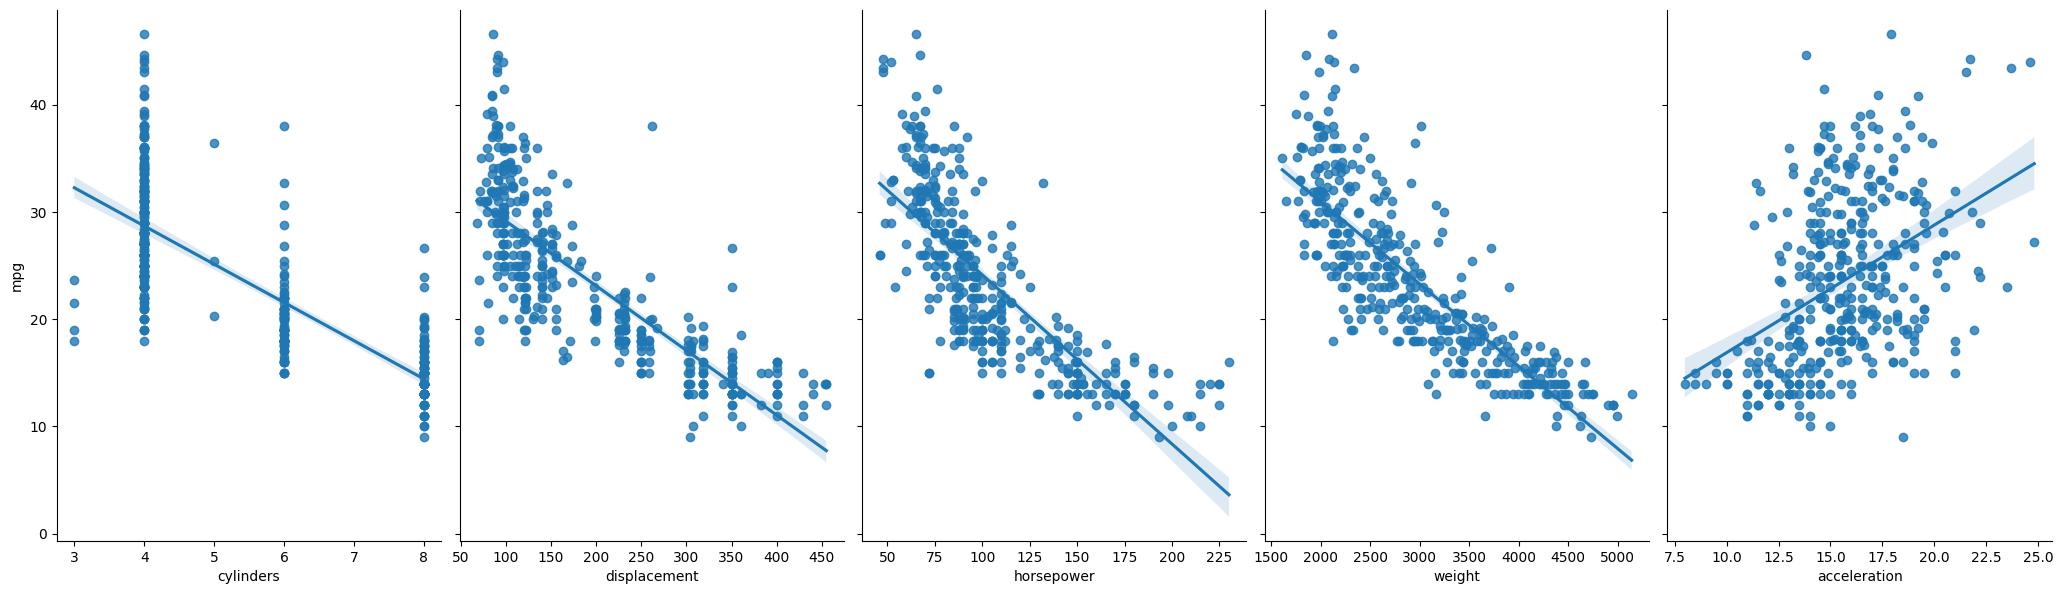

In [10]:
X_features = ["cylinders","displacement","horsepower","weight","acceleration"]
sns.pairplot(df, x_vars = X_features, y_vars = "mpg", height = 6, aspect = 0.7, kind = "reg")
plt.show()

### Step 6. What is the relationship between the feature and the target? (increasing or decreasing or none)

1. `x=cylinders` and `y=mpg`
2. `x=displacement` and `y=mpg`
3. `x=horsepower` and `y=mpg`
4. `x=weight` and `y=mpg`
5. `x=acceleration` and `y=mpg`

* **x=cylinders and y=mpg:** Decreasing. As the number of cylinders increases, mpg decreases.


* **x=displacement and y=mpg:** Decreasing. As engine displacement increases, mpg decreases.

* **x=horsepower and y=mpg:** Decreasing. As horsepower increases, mpg decreases.

* **x=weight and y=mpg:** Strongly decreasing. As vehicle weight increases, mpg decreases significantly.

* **x=acceleration and y=mpg:** Increasing (weak). Cars with higher acceleration show a slight increase in mpg.

### Step 7. Define the pipeline with pre-processing steps

Raw data is rarely ready for use in ML models. We often need steps such as:

- Handling missing values
- Encoding categorical variables
- Scaling numerical variables

Use `ColumnTransformer` to separate the preprocessing steps of the numerical features from the categorical ones.


In [11]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression

In [12]:
# Identify numerical & categorical columns to feature groups

numerical_features = ["cylinders","displacement","horsepower","weight","acceleration","model_year"]
categorical_features = ["origin","car_name"]

In [13]:
# Numerical pipeline

numerical_pipe = Pipeline(
    steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
  ]
     )

# Categorical pipeline

categorical_pipe = Pipeline(
    steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
 ]
    )

# combine both numerical pipeline and categorical pipeline

preprocessor = ColumnTransformer([
    ("num", numerical_pipe, numerical_features),
    ("cat", categorical_pipe, categorical_features)
]
  )

In [14]:
predictor = LinearRegression()

In [15]:
pipe = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", predictor),
    ]
)

### Step 8. Split the dataset into train and test sets

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

### Step 9.a Fit the pipeline on the training set

In [17]:
pipe.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['cylinders', 'displacement',
                                                   'horsepower', 'weight',
                                                   'acceleration',
                                                   'model_year']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['origin', 'car_name'])])),
                ('regressor', LinearRegression())])

### Step 9.b Identify the learned coefficients (for each feature) and the bias term

In [18]:
model = pipe.named_steps["regressor"]

# shows only the coefficients for the original numerical features
coefficients_df = pd.DataFrame({
    "Feature": numerical_features,
    "Coefficient": model.coef_ [:len(numerical_features)]
})

print(round(coefficients_df , 2))
print("\nBias Term (intercept) is:", round(model.intercept_))

        Feature  Coefficient
0     cylinders        -1.42
1  displacement        -1.40
2    horsepower        -0.59
3        weight        -3.02
4  acceleration        -1.19
5    model_year         2.11

Bias Term (intercept) is: 24


### Step 9.c how much `mpg` we gain if we decrease the weight of the automobile by `100kg`?

**Explain:**

The weight coefficient  = –3.02. This means for every 1 unit increase in weight, mpg decreases by 3.02.

1- We convert kg to lbs:
* 1 kg = 2.20462 lbs
* So:  100 kg x 2.20462 = 220.462 lbs ≈ 220 lbs

2- We convert pounds to thousand lbs. The dataset uses weight in 1000 lbs
* so: 220 / 1000 = 0.22 thousand lbs

3-  Apply the weight coefficient: We are reducing weight by 0.22 thousand lbs
* so: mpg = − 3.02 x (− 0.22)  = + 0.6644

4- Assumes weight is measured in 100 kg units (100kg = 0.1 metric tons)
* then, mpg = − 3.02 x (− 0.1) = + 0.302

**In Conclusion:**

If weight is in 1000 lbs:  
Reducing the weight by 100 kg increases mpg by approximately 0.66 mpg.

If weight is in 100 kg units:  
Reducing the weight by 100 kg increases mpg by about 0.30 mpg.


In [19]:
weight_coefficient = coefficients_df.loc[coefficients_df["Feature"] == "weight", "Coefficient"].iloc[0]

# dividing by 10 converts the weight from “per 1000 lbs” to “per 100 kg”

scaled_coefficient = weight_coefficient / 10

# -1 = reducing weight by one 100 kg unit

mpg_gain = scaled_coefficient * (-1)

print("MPG gain for reducing 100 kg is:", round(mpg_gain,3))

MPG gain for reducing 100 kg is: 0.302


### Step 10. Evaluate the pipeline on the test set

In [20]:
score = pipe.score(X_test, y_test)
score

0.7985702272128813